## Data Exploration 
Cleaned datasets live in "data/cleaned". There are 18 datasets from 2009 \~ 2026.

Each row is one lot in one fiscal year.

- **fy** is the fiscal year (2007 is the mislabeled 2009 file).

- **boro** is the borough: 1 Manhattan, 2 Bronx, 3 Brooklyn, 4 Queens, 5 Staten Island. block and lot together identify the parcel inside that borough.

- **mkt_land** is the Department of Finance market value of the land only, in dollars. This is the uncapped measurement.

- **mkt_total** is the market value of land plus building, in dollars. This appraisal is capped.

- **act_land** and **act_total** are the actual assessed values, the numbers the tax bill uses. For class 1 they are supposed to be 6 percent of the market values, then capped.


The 2010–2019 files use the older layout, so those two assessed columns still need a check

In [1]:
from pathlib import Path
import pandas as pd

files = sorted(Path("data/cleaned").glob("class1_*.csv"))
data = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
data["fy"] = data["fy"].astype(int)
data = data.sort_values(["boro", "block", "lot", "fy"])
data.head()

,fy,boro,block,lot,taxclass,mkt_land,mkt_total,act_land,act_total
0,2007,1,75,43,1,2000000.0,3520000.0,110243.0,194028.0
705591,2010,1,75,43,1,2500000.0,9990000.0,51469.0,205669.0
1412014,2011,1,75,43,1,4950000.0,8530000.0,123674.0,213120.0
2120086,2012,1,75,43,1,5690000.0,9480000.0,127917.0,213120.0
2828526,2013,1,75,43,1,5690000.0,9508000.0,129838.0,216960.0


### 1. Year-to-year change

Year-to-year change on the same lot. A capped total should pile up at the cap. Land should not.

In [2]:
data.groupby("fy").size().rename("lots")
g = data.groupby(["boro", "block", "lot"], sort=False)
data["d_land"] = g["mkt_land"].pct_change()
data["d_total"] = g["mkt_total"].pct_change()
chg = data.dropna(subset=["d_land", "d_total"])
chg = chg[chg["mkt_total"].gt(0) & chg["mkt_land"].gt(0)]

summary = chg.groupby("fy").agg(
    n=("d_total", "size"),
    median_land=("d_land", "median"),
    median_total=("d_total", "median"),
    share_total_under_1pct=("d_total", lambda s: (s <= 0.01).mean()),
    share_land_under_1pct=("d_land", lambda s: (s <= 0.01).mean()),
)
summary.round(3)

,n,median_land,median_total,share_total_under_1pct,share_land_under_1pct
fy,,,,,
2007,129,-0.950,-0.986,0.884,0.884
2010,703123,0.570,-0.030,0.761,0.094
2011,704308,1.007,-0.070,0.852,0.066
2012,706820,0.026,-0.034,0.716,0.211
2013,707206,0.000,-0.003,0.590,0.990
2014,707120,0.000,0.004,0.540,0.996
2015,706800,0.000,-0.002,0.600,0.985
2016,707075,0.000,0.024,0.437,0.986
2017,707234,0.000,0.066,0.374,0.975


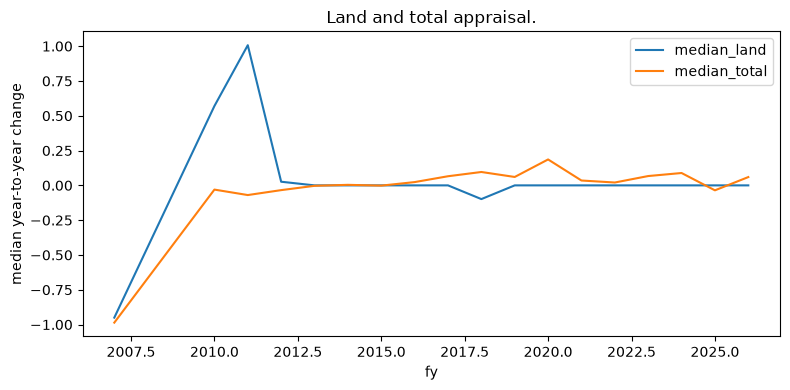

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
summary[["median_land", "median_total"]].plot(ax=ax)
ax.set_ylabel("median year-to-year change")
ax.set_title("Land and total appraisal.")
fig.tight_layout()

One building class, one borough, before fitting anything. Manhattan is `boro == 1`.

In [4]:
mn = chg[chg["boro"].eq(1) & chg["taxclass"].eq("1")]
mn.groupby("fy")[["d_land", "d_total"]].median().round(3)

,d_land,d_total
fy,,
2010,0.366,0.197
2011,0.871,-0.100
2012,0.102,0.011
2013,0.000,0.003
2014,0.000,0.030
2015,0.000,0.008
2016,0.000,0.000
2017,0.000,0.200
2018,-0.100,0.271
